# CNN - MobileNetV2
Bài toán phân loại ảnh chim (150 lớp) sử dụng MobileNetV2 với Transfer Learning.

In [1]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from google.colab import drive
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


## Load Dataset

In [2]:
drive.mount('/content/drive')

PATH_AUGMENTED_ZIP  = '/content/drive/MyDrive/CS231/augmented_dataset.zip'
EXTRACT_DIR_AUG   = '/content/augmented_dataset'

def extract_zip(zip_path, extract_path):
    if not os.path.exists(zip_path):
        print(f'LOI: Khong tim thay file {zip_path}.')
        return
    if not os.path.exists(extract_path):
        os.makedirs(extract_path, exist_ok=True)
        print(f'Dang giai nen {zip_path}...')
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(extract_path)
        print(f'Giai nen xong: {extract_path}')
    else:
        print(f'Thu muc da ton tai: {extract_path}')

extract_zip(PATH_AUGMENTED_ZIP, EXTRACT_DIR_AUG)

AUG_PATH = {
    'train': os.path.join(EXTRACT_DIR_AUG, 'train'),
    'val':   os.path.join(EXTRACT_DIR_AUG, 'val'),
    'test':  os.path.join(EXTRACT_DIR_AUG, 'test')
}

Mounted at /content/drive
Dang giai nen /content/drive/MyDrive/CS231/augmented_dataset.zip...
Giai nen xong: /content/augmented_dataset


## Build Model - MobileNetV2

In [3]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import (Input, GlobalAveragePooling2D,
                                     Dense, Dropout, BatchNormalization)
from tensorflow.keras.models import Model

def build_mobilenetv2(input_shape=(224, 224, 3), num_classes=150):

    input_tensor = Input(shape=input_shape)

    backbone = MobileNetV2(include_top=False,
                              weights=None,
                              input_tensor=input_tensor)

    backbone.trainable = True

    x = backbone.output

    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation='softmax')(x)

    return Model(inputs=input_tensor, outputs=output)

model = build_mobilenetv2(input_shape=(224, 224, 3), num_classes=150)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,455,254 (9.37 MB)

 Trainable params: 2,418,582 (9.23 MB)

 Non-trainable params: 36,672 (143.25 KB)

## Hàm Đánh Giá và Vẽ Biểu Đồ

In [12]:
def evaluate_and_plot(model, test_generator, title="Model Evaluation"):
    test_generator.reset()
    Y_pred = model.predict(test_generator)
    y_pred = np.argmax(Y_pred, axis=1)
    y_true = test_generator.classes

    acc = accuracy_score(y_true, y_pred)
    pre, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')

    print(f"\n--- {title} ---")
    print(f"Accuracy : {acc*100:.2f}%")
    print(f"Precision: {pre:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=False, cmap='Blues')
    plt.title(f'Confusion Matrix - {title}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

def plot_training_history(history, title="MobileNetV2"):
    acc     = history.history.get('accuracy', history.history.get('acc'))
    val_acc = history.history.get('val_accuracy', history.history.get('val_acc'))
    loss     = history.history.get('loss')
    val_loss = history.history.get('val_loss')
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc,     'b-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
    plt.title(f'Accuracy - {title}')
    plt.xlabel('Epochs'); plt.ylabel('Accuracy')
    plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss,     'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
    plt.title(f'Loss - {title}')
    plt.xlabel('Epochs'); plt.ylabel('Loss')
    plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout(); plt.show()

def plot_sample_predictions(model, test_generator, num_samples=5):
    test_generator.reset()
    Y_pred = model.predict(test_generator)
    y_pred = np.argmax(Y_pred, axis=1)
    y_true = test_generator.classes
    class_names = list(test_generator.class_indices.keys())

    correct_idx   = np.where(y_pred == y_true)[0]
    incorrect_idx = np.where(y_pred != y_true)[0]

    def draw_grid(indices, status_title):
        plt.figure(figsize=(20, 5))
        plt.suptitle(f"Ví dụ dự đoán {status_title}", fontsize=16, fontweight='bold')
        selected = np.random.choice(indices, min(num_samples, len(indices)), replace=False)
        for i, idx in enumerate(selected):
            batch_idx       = idx // test_generator.batch_size
            img_idx_in_batch = idx % test_generator.batch_size
            imgs, _ = test_generator[batch_idx]
            img = imgs[img_idx_in_batch]
            if img.max() <= 1.0:
                img = ((img+1)* 125.5).astype('uint8')
            else:
                img = img.astype('uint8')
            plt.subplot(1, num_samples, i + 1)
            plt.imshow(img)
            true_label = class_names[y_true[idx]]
            pred_label = class_names[y_pred[idx]]
            color = 'green' if status_title == "ĐÚNG" else 'red'
            plt.title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=10)
            plt.axis('off')
        plt.tight_layout(); plt.show()

    if len(correct_idx) > 0:   draw_grid(correct_idx,   "ĐÚNG")
    if len(incorrect_idx) > 0: draw_grid(incorrect_idx, "SAI")

## Training

In [7]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = datagen.flow_from_directory(AUG_PATH['train'], target_size=(224, 224),
                                        batch_size=32, class_mode='categorical')
val_gen   = datagen.flow_from_directory(AUG_PATH['val'],   target_size=(224, 224),
                                        batch_size=32, class_mode='categorical')
test_gen  = datagen.flow_from_directory(AUG_PATH['test'],  target_size=(224, 224),
                                        batch_size=32, class_mode='categorical', shuffle=False)

early_stop = EarlyStopping(monitor='val_loss', patience=8,
                            restore_best_weights=True, verbose=1)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=4, min_lr=1e-6, verbose=1)
callbacks_list = [early_stop, reduce_lr]

model_mob = build_mobilenetv2()
model_mob.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

print("\n[MobileNetV2] Training")
history_mob = model_mob.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    callbacks=callbacks_list
)

Found 30000 images belonging to 150 classes.
Found 4248 images belonging to 150 classes.
Found 4468 images belonging to 150 classes.

[MobileNetV2] Training
Epoch 1/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 199s 154ms/step - accuracy: 0.0723 - loss: 5.0971 - val_accuracy: 0.0078 - val_loss: 11.8832 - learning_rate: 0.0010
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 112s 119ms/step - accuracy: 0.3201 - loss: 3.3723 - val_accuracy: 0.0064 - val_loss: 28.8559 - learning_rate: 0.0010
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 111s 119ms/step - accuracy: 0.5344 - loss: 2.5407 - val_accuracy: 0.0064 - val_loss: 28.8220 - learning_rate: 0.0010
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 110s 117ms/step - accuracy: 0.6419 - loss: 2.1875 - val_accuracy: 0.0066 - val_loss: 17.8313 - learning_rate: 0.0010
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 111s 118ms/step - accuracy: 0.7085 - loss: 1.9703 - val_accuracy: 0.0118 - val_loss: 8.8116 - learning_rate: 0.0010
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 111s 118ms/step - a

### Kết Quả

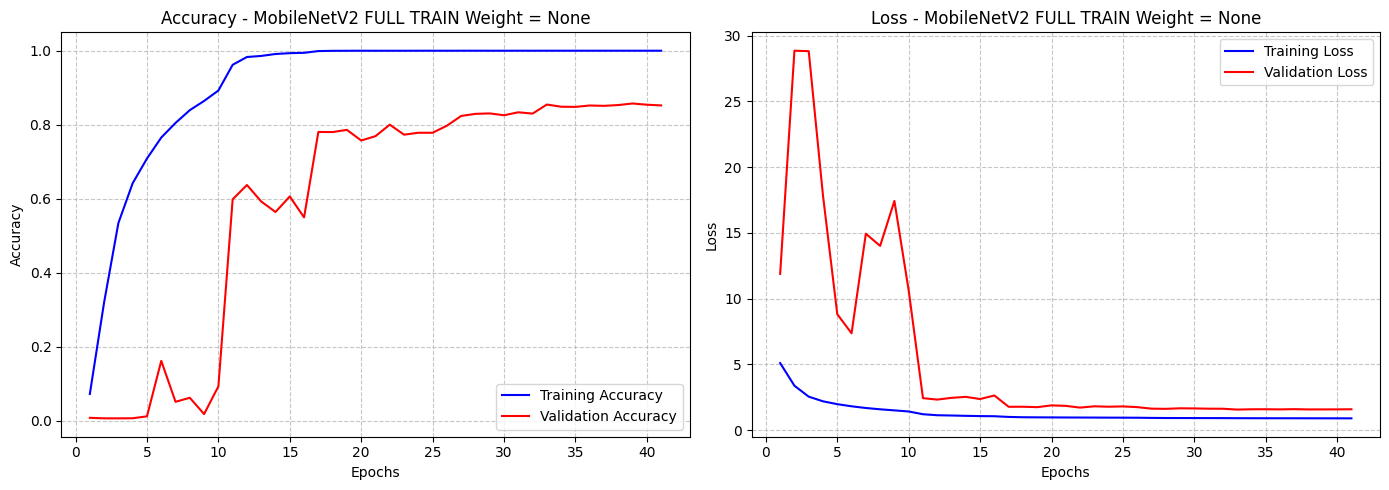

140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step

--- MobileNetV2 Full Train Weight = None ---
Accuracy : 84.96%
Precision: 0.8621
Recall   : 0.8498
F1-score : 0.8507


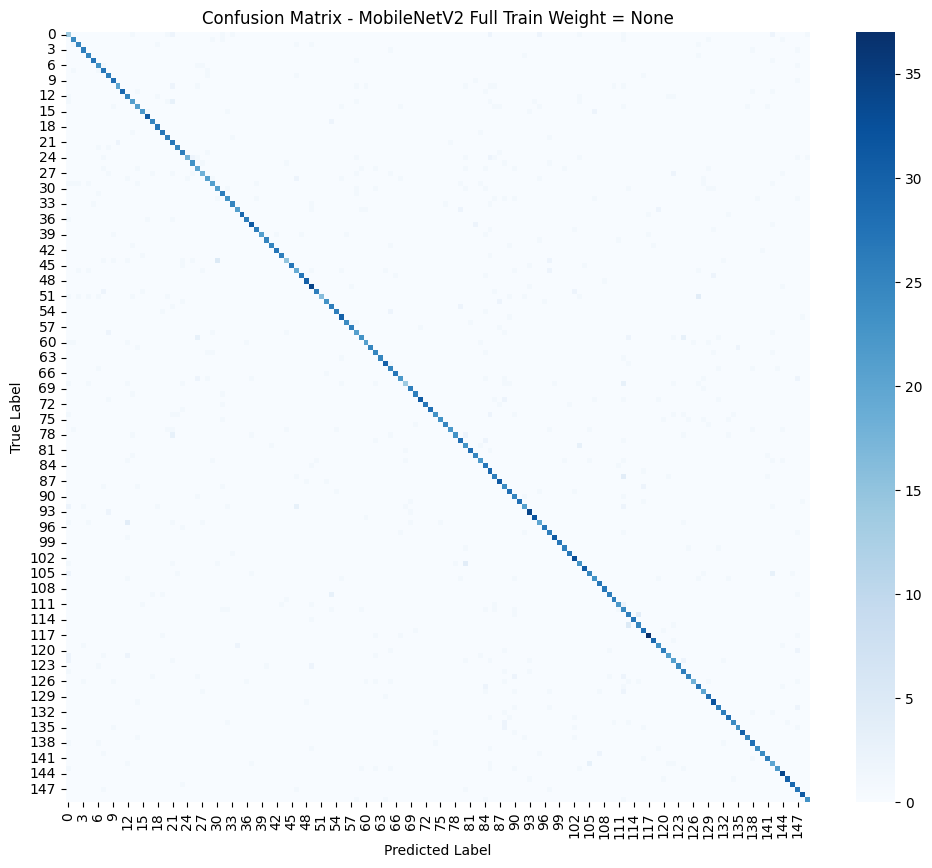

140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step


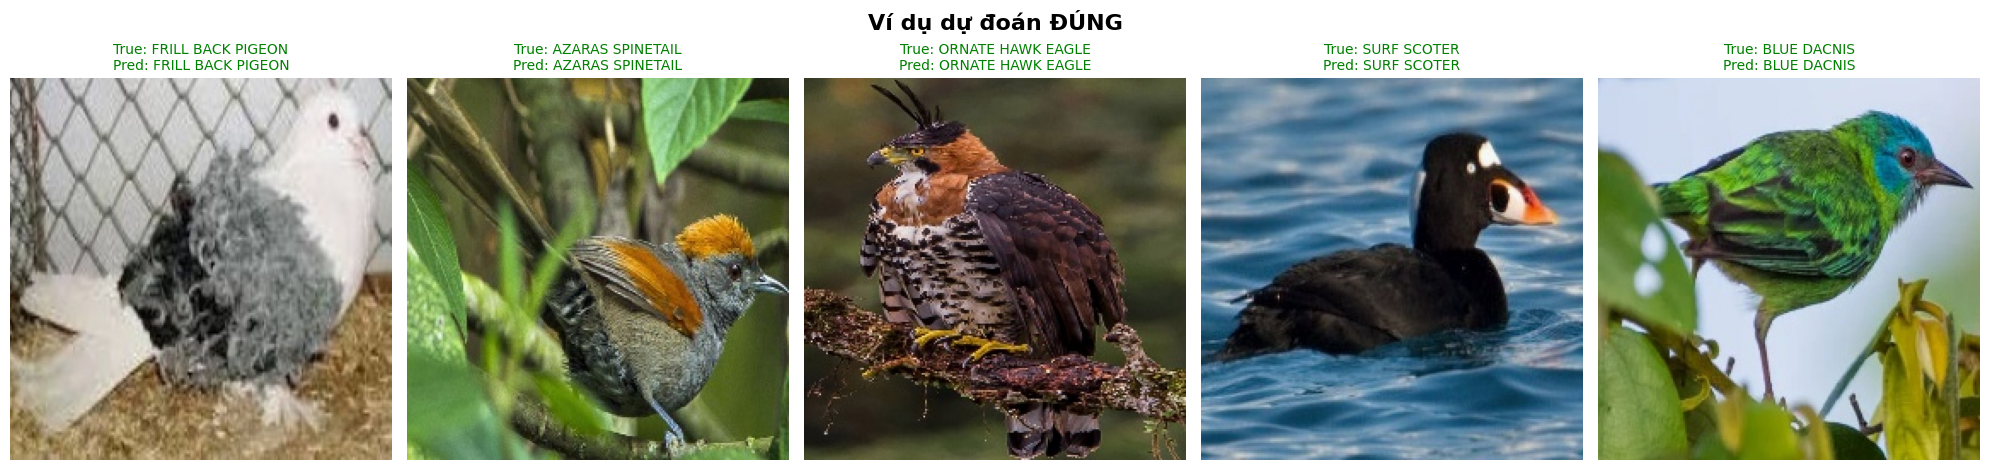

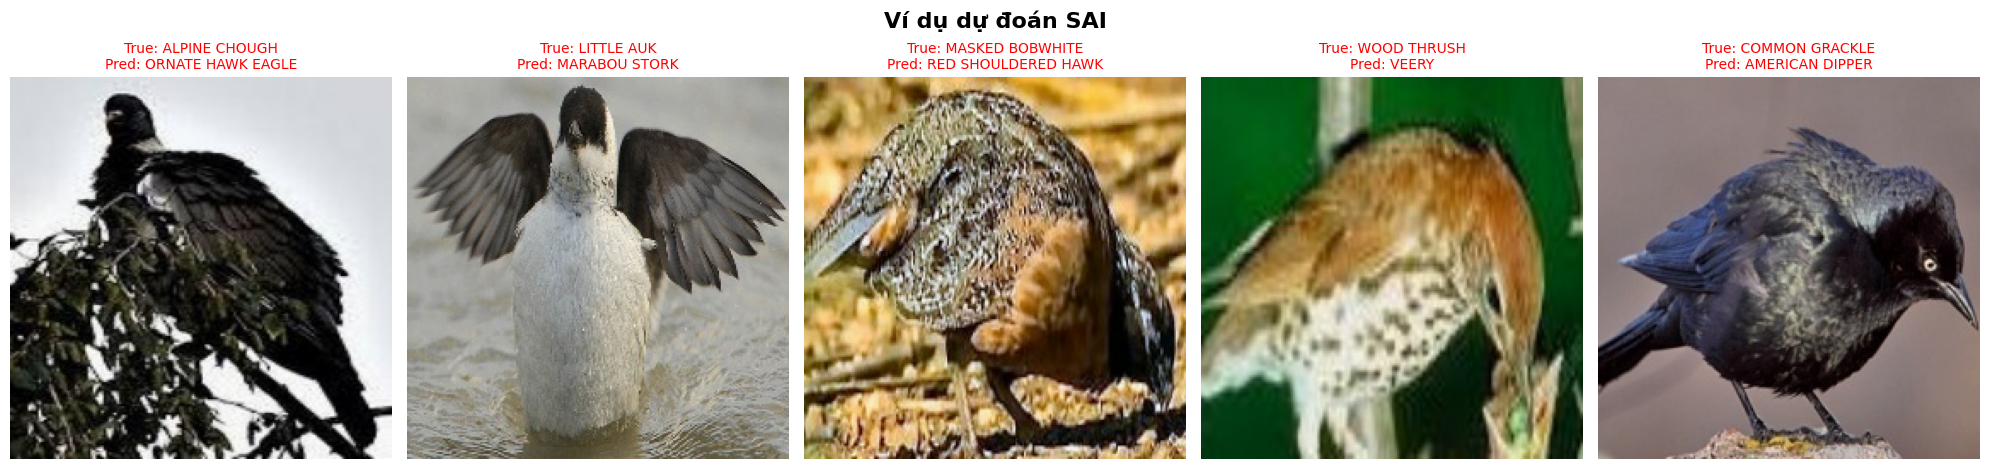

In [13]:
plot_training_history(history_mob, title="MobileNetV2 FULL TRAIN Weight = None")
evaluate_and_plot(model_mob, test_gen, title="MobileNetV2 Full Train Weight = None")
plot_sample_predictions(model_mob, test_gen, num_samples=5)